## Importy

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, recall_score
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Wczytanie danych

In [2]:
df = pd.read_csv("Heart_disease_cleveland_new.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


## Opis danych

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
target
0    164
1    139
Name: count, dtype: int64


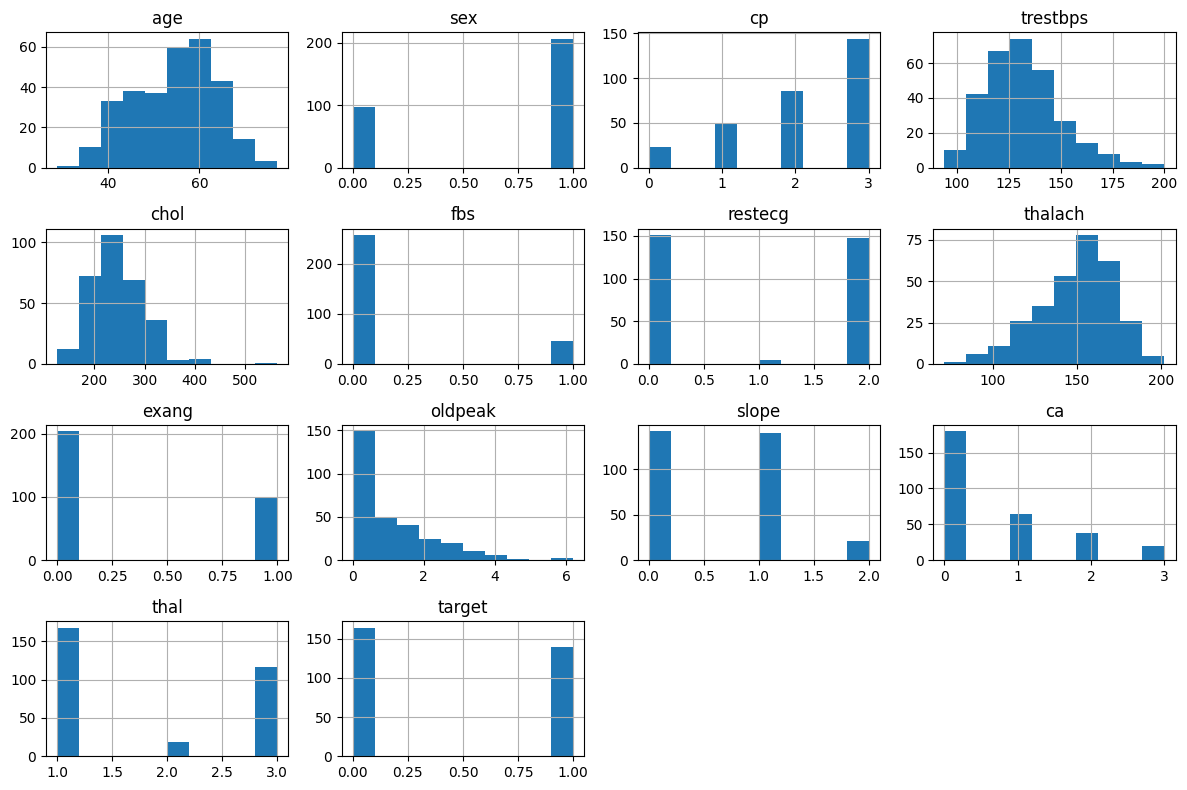

In [ ]:
df.describe()
df.info()
print(df['target'].value_counts())

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

Zbiór zawiera 303 rekordy i 14 kolumn - 13 cech pacjenta i kolumnę target
(0 = zdrowy, 1 = chory). Brak wartości brakujących.

Oznaczenia poszczególnych cech:
- age - wiek
- sex - płeć (0 = kobieta, 1 = mężczyzna)
- trestbps - ciśnienie krwi w spoczynku
- chol - poziom cholesterolu
- fbs - cukier we krwi na czczo
- thalach - maksymalne tętno
- itd.

Typy kolumn:
- kategoryczne: sex, cp, fbs, restecg, exang, slope, ca, thal, target
- ciągłe: age, trestbps, chol, thalach, oldpeak

##  Trening modelu i analiza wyników

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(242, 13) (61, 13)


              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



Text(0.5, 1.0, 'Macierz pomyłek')

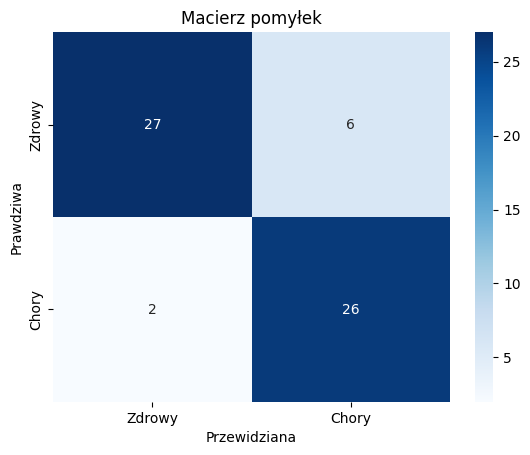

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Zdrowy', 'Chory'], yticklabels=['Zdrowy', 'Chory'])
plt.xlabel('Przewidziana')
plt.ylabel('Prawdziwa')
plt.title('Macierz pomyłek')

Macierz pomyłek:
- TN = 27, zdrowi poprawnie wykryci
- TP = 26, chorzy poprawnie wykryci
- FP = 6, zdrowi jako chorzy
- FN = 2, chorzy jako zdrowi

Precision = 0.81, 81% chorych z oznaczonych

Recall = 0.93, z wszystkich chorych 93% wykrytych

W naszym przypadku recall jest ważniejsze od precision, ponieważ najgorszy bład dla nas to False Negative, czyli chorzy zaklasyfikowani jako zdrowi, co jest największym zagrożeniem dla pacjenta.

## Krzywa ROC

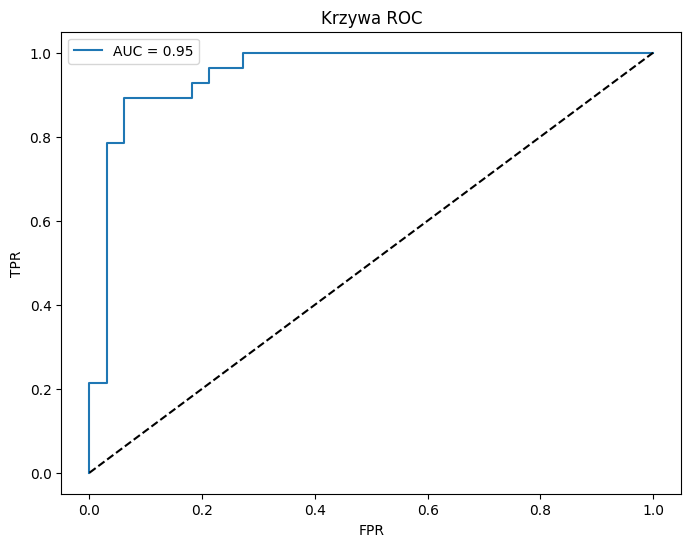

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Krzywa ROC')
plt.legend()
plt.show()

Przerywana linia - losowy klasyfikator AUC = 0.5 (zgadywanie).

Krzywa ROC - pokazuje kompromis pomiędzy TPR (wykryci chorzy), a FPR (zdrowi oznaczeni jako chorzy).

AUC - pole pod krzywą, 95% oznacza, że w tylu procentach przypadków poprawnie przypisuje wyższe prawdopodobienstwo choremu pacjentowi.

## Normalizacja i standaryzacja

In [7]:
results = {}

results['brak'] = {
    'acc': accuracy_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred)
}

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
m = LogisticRegression(max_iter=1000)
m.fit(X_train_std, y_train)
y_pred_std = m.predict(X_test_std)
results['standaryzacja'] = {
    'acc': accuracy_score(y_test, y_pred_std),
    'recall': recall_score(y_test, y_pred_std)
}

scaler2 = MinMaxScaler()
X_train_norm = scaler2.fit_transform(X_train)
X_test_norm = scaler2.transform(X_test)
m2 = LogisticRegression(max_iter=1000)
m2.fit(X_train_norm, y_train)
y_pred_norm = m2.predict(X_test_norm)
results['normalizacja'] = {
    'acc': accuracy_score(y_test, y_pred_norm),
    'recall': recall_score(y_test, y_pred_norm)
}

pd.DataFrame(results).T

,acc,recall
brak,0.868852,0.928571
standaryzacja,0.868852,0.928571
normalizacja,0.852459,0.892857


Standaryzacja dała identyczne wyniki jak surowe dane.
Normalizacja nieznacznie pogorszyła wyniki.

Skalowanie ma na celu wyrównanie skal cech (np. chol: 126–564 vs oldpeak: 0–6.2), 
żeby algorytm traktował je równo podczas uczenia. Przy naszym zbiorze model dobrze sobie radzi bez tych metod.

### Badanie wpływu siły regularyzacji

In [8]:
results_c = {}

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    m = LogisticRegression(max_iter=1000, C=C)
    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    results_c[C] = {
    'acc': accuracy_score(y_test, y_p),
    'recall': recall_score(y_test, y_p),
    'n_iter': m.n_iter_[0]
}

pd.DataFrame(results_c).T

,acc,recall,n_iter
0.001,0.868852,0.750000,7.0
0.010,0.885246,0.892857,8.0
0.100,0.868852,0.928571,7.0
1.000,0.868852,0.928571,9.0
10.000,0.868852,0.928571,11.0
100.000,0.868852,0.928571,11.0


Parametr C kontroluje siłę regularyzacji - im mniejsze C, tym model jest 
bardziej karany i ma mniejszą swobodę dopasowania do danych.

Przy C=0.001 recall spada do 0.75 - model jest zbyt mocno ograniczony. 
Przy C=0.01 (acc=0.89, recall=0.89), najlepsze wyniki względem accuracy. 
Od C=0.1 (najlepszy recall) wzwyż wyniki stabilizują się i większe C nic już nie zmienia.

### Badanie wpływu l1_ratio

In [9]:
results_ratio = {}

for ratio in [0.0, 0.25, 0.5, 0.75, 1.0]:
    m = LogisticRegression(
        solver='saga',
        l1_ratio=ratio,
        C=1.0,
        max_iter=10000
    )
    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    results_ratio[ratio] = {
        'acc': accuracy_score(y_test, y_p),
        'recall': recall_score(y_test, y_p),
        'n_iter': m.n_iter_[0]
    }

pd.DataFrame(results_ratio).T

,acc,recall,n_iter
0.00,0.868852,0.928571,23.0
0.25,0.868852,0.928571,20.0
0.50,0.868852,0.928571,19.0
0.75,0.868852,0.928571,23.0
1.00,0.868852,0.928571,22.0


Zmiana l1_ratio nie wpłynęła na wyniki modelu - acc i recall są identyczne dla wszystkich wartości. Na tym zbiorze danych nie ma znaczenia jak bardzo regularyzacja jest typu l1 czy l2.

## Interakcja C i l1_ratio

In [10]:
import itertools

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]

results = []

for C, ratio in itertools.product(C_values, l1_ratios):
    m = LogisticRegression(solver='saga', l1_ratio=ratio, C=C, max_iter=10000)
    m.fit(X_train_std, y_train)
    y_p = m.predict(X_test_std)
    results.append({
        'C': C,
        'l1_ratio': ratio,
        'acc': accuracy_score(y_test, y_p),
        'recall': recall_score(y_test, y_p)
    })

df_results = pd.DataFrame(results)

acc_table = df_results.pivot(index='C', columns='l1_ratio', values='acc')
recall_table = df_results.pivot(index='C', columns='l1_ratio', values='recall')

print("Accuracy:")
display(acc_table)
print("Recall:")
display(recall_table)

Accuracy:


l1_ratio,0.00,0.25,0.50,0.75,1.00
C,,,,,
0.001,0.868852,0.540984,0.459016,0.540984,0.540984
0.010,0.885246,0.885246,0.721311,0.540984,0.540984
0.100,0.868852,0.852459,0.852459,0.852459,0.852459
1.000,0.868852,0.868852,0.868852,0.868852,0.868852
10.000,0.868852,0.868852,0.868852,0.868852,0.868852
100.000,0.868852,0.868852,0.868852,0.868852,0.868852


Recall:


l1_ratio,0.00,0.25,0.50,0.75,1.00
C,,,,,
0.001,0.750000,0.000000,1.000000,0.000000,0.000000
0.010,0.892857,0.821429,0.464286,0.000000,0.000000
0.100,0.928571,0.892857,0.892857,0.857143,0.857143
1.000,0.928571,0.928571,0.928571,0.928571,0.928571
10.000,0.928571,0.928571,0.928571,0.928571,0.928571
100.000,0.928571,0.928571,0.928571,0.928571,0.928571


Wniosek: l1_ratio ma znaczenie tylko przy małym C. Przy dużym C oba typy l1 i l2 dają ten sam efekt.

## Cross validation

In [11]:
model_cv = LogisticRegression(max_iter=1000, C=0.01)
print("Bez stratyfikacji:")
for k in [2, 5, 10]:
    kf = KFold(n_splits=k)
    scores = cross_val_score(model_cv, X_train_std, y_train, cv=kf, scoring='recall')
    print(f"{k}-fold, mean={scores.mean():.3f}, std={scores.std():.3f}")

print("\nZ stratyfikacją:")

for k in [2, 5, 10]:
    skf = StratifiedKFold(n_splits=k)
    scores = cross_val_score(model_cv, X_train_std, y_train, cv=skf, scoring='recall')
    print(f"{k}-fold, mean={scores.mean():.3f}, std={scores.std():.3f}")

Bez stratyfikacji:
2-fold, mean=0.698, std=0.071
5-fold, mean=0.744, std=0.055
10-fold, mean=0.758, std=0.086

Z stratyfikacją:
2-fold, mean=0.721, std=0.012
5-fold, mean=0.730, std=0.029
10-fold, mean=0.757, std=0.100


Przy 2-fold stratyfikacja wyraźnie obniża std (z 0.071 na 0.012) bez niej podział może trafić na nierówny rozkład klas. Przy większej liczbie foldów różnice się wyrównują.